# Pairwise linkage between within-family entrenched sites

Test whether amino acid identities at within-family entrenched sites co-vary across
V genes within a family. If intra-chain epistasis between these sites were the primary
driver of entrenchment, we would expect tight co-variation (high Cramér's V). If the
sites vary more independently, the constraint is more likely to come from outside the
heavy chain (i.e., interactions with antigen and light chain).

In [1]:
from itertools import combinations

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

from utils import load_entrenched_sites, sort_antibody_sites, GERMLINE_PATH_DICTIONARY

In [2]:
numbering_scheme = 'chothia'

# Load germline codon table
codons_df = pd.read_csv(GERMLINE_PATH_DICTIONARY[numbering_scheme], dtype={'site': str})

# Load entrenched sites (within-family only)
_, _, _, _, within_dfs, _ = load_entrenched_sites(numbering_scheme)

# Get unique within-family entrenched sites per V family
within_entrenched = within_dfs[['site', 'v_family']].drop_duplicates()
print("Within-family entrenched sites:")
for vfam, group in within_entrenched.groupby('v_family'):
    sites = sort_antibody_sites(group['site'].unique())
    print(f"  {vfam}: {sites}")

Within-family entrenched sites:
  IGHV1: ['33', '50', '52']
  IGHV3: ['33', '35', '50', '52', '53']
  IGHV4: ['33', '50']


## Cramér's V for all pairs of entrenched sites within each V family

For each V family, pivot the germline codons table so that each row is a V gene
and each column is the amino acid at an entrenched site. Then compute Cramér's V
for every pair of entrenched sites to measure co-variation.

In [3]:
def cramers_v(contingency_table):
    """Compute Cramér's V from a contingency table."""
    chi2, p, dof, _ = chi2_contingency(contingency_table)
    n = contingency_table.values.sum()
    k = min(contingency_table.shape) - 1
    if k == 0 or n == 0:
        return 0.0, p
    v = np.sqrt(chi2 / (n * k))
    return v, p


results = []

for v_family in sorted(within_entrenched['v_family'].unique()):
    # Get entrenched sites for this family
    sites = within_entrenched[within_entrenched['v_family'] == v_family]['site'].unique()
    sites = sort_antibody_sites(sites)

    if len(sites) < 2:
        continue

    # Pivot: rows = V genes in this family, columns = amino acid at each entrenched site
    family_codons = codons_df[codons_df['v_family'] == v_family].copy()
    family_codons = family_codons[family_codons['site'].isin(sites)]
    pivot = family_codons.pivot(index='v_gene', columns='site', values='amino_acid')

    n_genes = len(pivot)

    for site_a, site_b in combinations(sites, 2):
        if site_a not in pivot.columns or site_b not in pivot.columns:
            continue

        # Drop V genes with missing data at either site
        pair_df = pivot[[site_a, site_b]].dropna()
        if len(pair_df) < 5:
            continue

        ct = pd.crosstab(pair_df[site_a], pair_df[site_b])

        # Need at least 2 categories in each dimension
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue

        v, p = cramers_v(ct)

        results.append({
            'v_family': v_family,
            'site_a': site_a,
            'site_b': site_b,
            'cramers_v': v,
            'p_value': p,
            'n_genes': len(pair_df),
            'n_aa_site_a': ct.shape[0],
            'n_aa_site_b': ct.shape[1],
        })

results_df = pd.DataFrame(results).sort_values('cramers_v', ascending=False)
results_df

,v_family,site_a,site_b,cramers_v,p_value,n_genes,n_aa_site_a,n_aa_site_b
11,IGHV3,50,53,0.713674,2.829396e-24,85,10,6
10,IGHV3,50,52,0.679426,1.225168e-22,81,10,7
1,IGHV1,33,52,0.663582,2.584970e-09,41,6,6
12,IGHV3,52,53,0.653139,5.357999e-22,81,7,6
2,IGHV1,50,52,0.600632,9.584217e-06,41,5,6
3,IGHV3,33,35,0.586502,3.430843e-09,85,9,4
5,IGHV3,33,52,0.578769,2.099934e-14,81,9,7
6,IGHV3,33,53,0.559765,6.086080e-12,85,9,6
4,IGHV3,33,50,0.554859,2.478401e-15,85,9,10
7,IGHV3,35,50,0.542037,2.169432e-06,85,4,10


## Show the contingency tables for each pair

Display the actual amino acid co-occurrence counts to see whether the sites
have strict pairwise coupling or more independent variation.

In [4]:
for v_family in sorted(within_entrenched['v_family'].unique()):
    sites = within_entrenched[within_entrenched['v_family'] == v_family]['site'].unique()
    sites = sort_antibody_sites(sites)

    if len(sites) < 2:
        continue

    family_codons = codons_df[codons_df['v_family'] == v_family].copy()
    family_codons = family_codons[family_codons['site'].isin(sites)]
    pivot = family_codons.pivot(index='v_gene', columns='site', values='amino_acid')

    for site_a, site_b in combinations(sites, 2):
        if site_a not in pivot.columns or site_b not in pivot.columns:
            continue

        pair_df = pivot[[site_a, site_b]].dropna()
        ct = pd.crosstab(pair_df[site_a], pair_df[site_b], margins=True)

        # Look up Cramér's V from results
        row = results_df[
            (results_df['v_family'] == v_family)
            & (results_df['site_a'] == site_a)
            & (results_df['site_b'] == site_b)
        ]
        v_val = row['cramers_v'].values[0] if len(row) > 0 else float('nan')

        print(f"\n{'='*60}")
        print(f"{v_family}  site {site_a} (rows) vs site {site_b} (cols)")
        print(f"Cramér's V = {v_val:.3f}")
        print(ct)
        print()


IGHV1  site 33 (rows) vs site 50 (cols)
Cramér's V = 0.437
50    G  I  L  R   W  All
33                       
A    10  0  0  5   7   22
D     0  0  0  0   3    3
G     0  0  0  0   3    3
S     1  0  0  0   0    1
T     0  0  0  1   0    1
Y     0  3  1  2   5   11
All  11  3  1  8  18   41


IGHV1  site 33 (rows) vs site 52 (cols)
Cramér's V = 0.664
52   D   I   N  S  T  V  All
33                          
A    0  15   4  0  0  3   22
D    0   0   3  0  0  0    3
G    0   0   0  3  0  0    3
S    1   0   0  0  0  0    1
T    0   1   0  0  0  0    1
Y    1   0   8  0  2  0   11
All  2  16  15  3  2  3   41


IGHV1  site 50 (rows) vs site 52 (cols)
Cramér's V = 0.601
52   D   I   N  S  T  V  All
50                          
G    1  10   0  0  0  0   11
I    0   0   3  0  0  0    3
L    1   0   0  0  0  0    1
R    0   6   2  0  0  0    8
W    0   0  10  3  2  3   18
All  2  16  15  3  2  3   41


IGHV3  site 33 (rows) vs site 35 (cols)
Cramér's V = 0.587
35   D   H   N   S  All
33    


IGHV3  site 35 (rows) vs site 52 (cols)
Cramér's V = 0.483
52   G  K  N  R   S  W  Y  All
35                            
D    0  0  0  1   0  0  0    1
H    6  0  1  3  22  3  1   36
N    0  1  1  0  17  0  0   19
S    0  5  3  3   6  0  8   25
All  6  6  5  7  45  3  9   81


IGHV3  site 35 (rows) vs site 53 (cols)
Cramér's V = 0.453
53    D  G   N   S  T  Y  All
35                           
D     0  0   1   0  0  0    1
H    17  1  12   0  6  0   36
N     1  0   7  11  0  0   19
S     5  1   3  17  0  3   29
All  23  2  23  28  6  3   85


IGHV3  site 50 (rows) vs site 52 (cols)
Cramér's V = 0.679
52   G  K  N  R   S  W  Y  All
50                            
A    6  0  0  0   8  0  0   14
F    0  0  0  4   0  0  0    4
G    0  0  3  0  10  0  0   13
L    0  0  0  0   5  0  0    5
N    0  4  0  0   0  0  0    4
Q    0  0  1  0   0  0  0    1
R    0  2  1  3   0  0  0    6
S    0  0  0  0   6  0  0    6
V    0  0  0  0   7  3  9   19
Y    0  0  0  0   9  0  0    9
All  6  6  5  7  45

## Comparison: Cramér's V at entrenched sites vs. all other diverse site pairs

To contextualize the entrenched-site linkage values, compute Cramér's V for all
pairs of germline-diverse sites (Shannon entropy > 0) within each family and
compare the distributions.

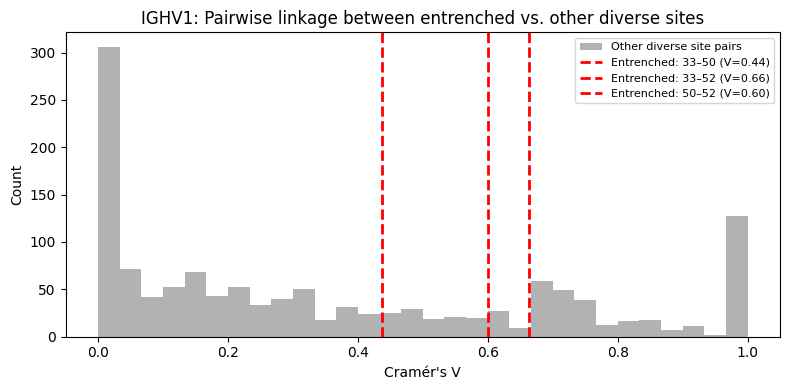


IGHV1 summary:
  Entrenched pairs — median Cramér's V: 0.601 (n=3)
  Other pairs      — median Cramér's V: 0.261 (n=1323)


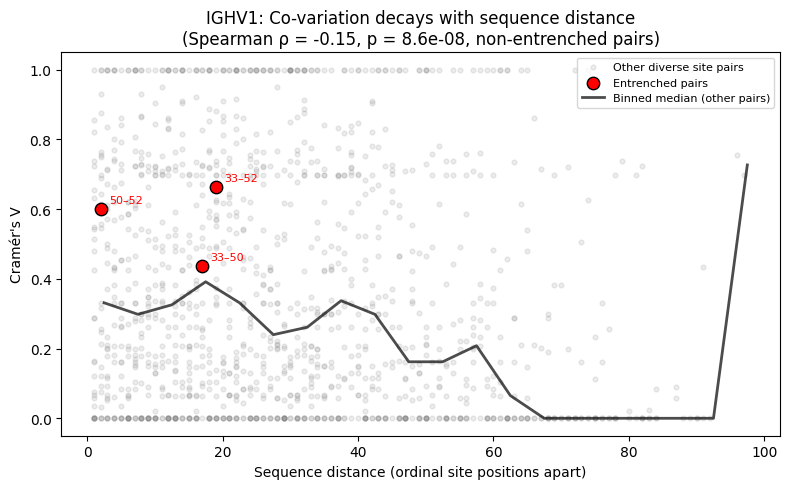

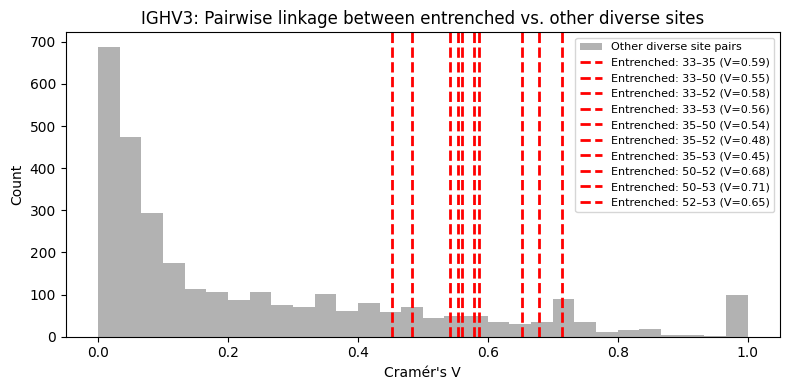


IGHV3 summary:
  Entrenched pairs — median Cramér's V: 0.569 (n=10)
  Other pairs      — median Cramér's V: 0.116 (n=3082)


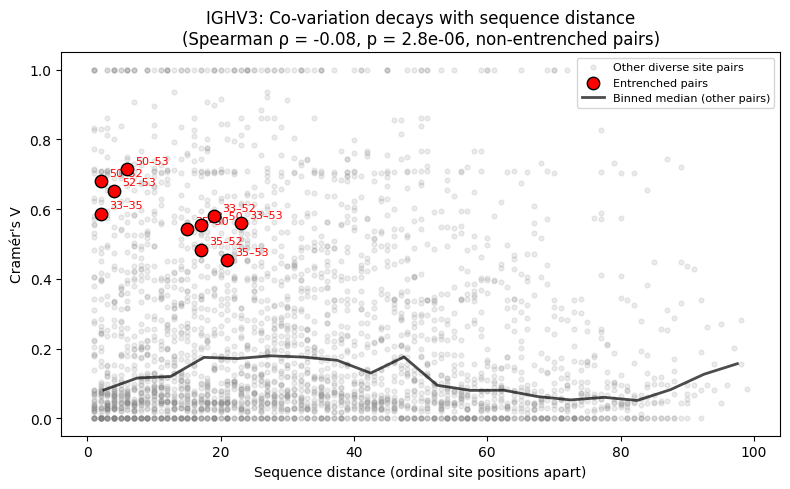

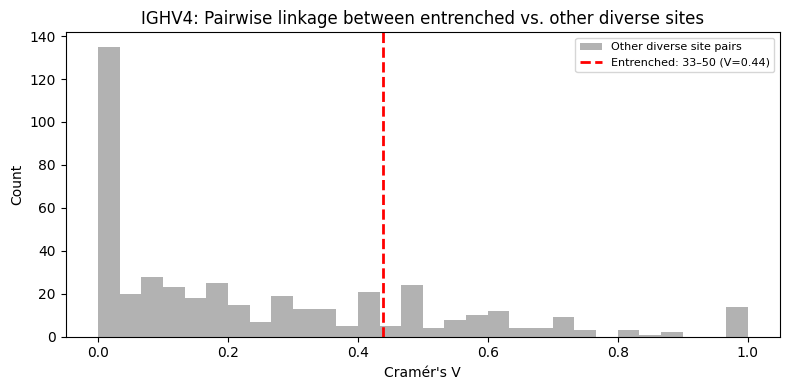


IGHV4 summary:
  Entrenched pairs — median Cramér's V: 0.438 (n=1)
  Other pairs      — median Cramér's V: 0.160 (n=445)


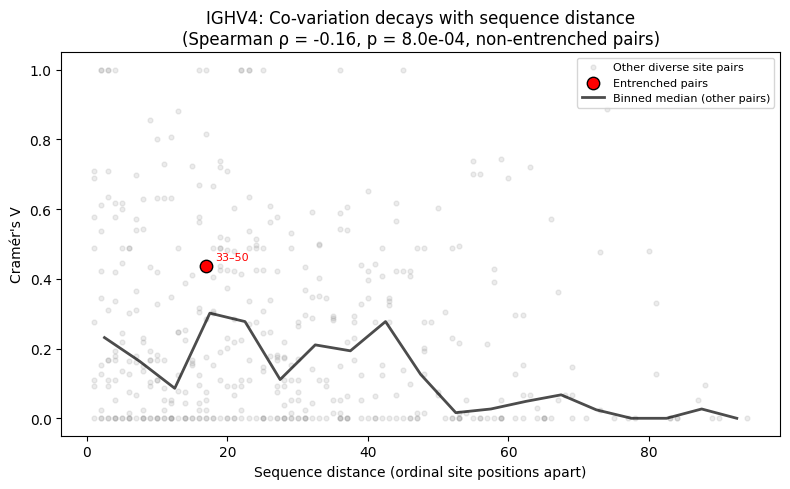

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

for v_family in sorted(within_entrenched['v_family'].unique()):
    entrenched_sites_list = set(
        within_entrenched[within_entrenched['v_family'] == v_family]['site'].unique()
    )

    family_codons = codons_df[codons_df['v_family'] == v_family].copy()

    # Find all sites with germline diversity (>1 unique amino acid)
    diverse_sites = (
        family_codons.groupby('site')['amino_acid']
        .nunique()
        .loc[lambda x: x > 1]
        .index.tolist()
    )

    # Build ordinal position map: sorted Chothia sites -> integer index
    all_sites_ordered = sort_antibody_sites(
        family_codons['site'].unique().tolist()
    )
    site_to_ordinal = {s: i for i, s in enumerate(all_sites_ordered)}

    pivot = family_codons[family_codons['site'].isin(diverse_sites)].pivot(
        index='v_gene', columns='site', values='amino_acid'
    )

    all_pairs = []
    for sa, sb in combinations(diverse_sites, 2):
        if sa not in pivot.columns or sb not in pivot.columns:
            continue
        pair_df = pivot[[sa, sb]].dropna()
        if len(pair_df) < 5:
            continue
        ct = pd.crosstab(pair_df[sa], pair_df[sb])
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue
        v, p = cramers_v(ct)
        is_entrenched_pair = (sa in entrenched_sites_list) and (sb in entrenched_sites_list)
        seq_dist = abs(site_to_ordinal[sa] - site_to_ordinal[sb])
        all_pairs.append({
            'site_a': sa, 'site_b': sb,
            'cramers_v': v, 'p_value': p,
            'entrenched_pair': is_entrenched_pair,
            'seq_distance': seq_dist,
        })

    all_pairs_df = pd.DataFrame(all_pairs)
    if all_pairs_df.empty:
        continue

    ent = all_pairs_df[all_pairs_df['entrenched_pair']]
    non_ent = all_pairs_df[~all_pairs_df['entrenched_pair']]

    # --- Histogram plot (existing) ---
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(non_ent['cramers_v'], bins=30, alpha=0.6, label='Other diverse site pairs', color='gray')
    for _, row in ent.iterrows():
        ax.axvline(row['cramers_v'], color='red', linewidth=2, linestyle='--',
                   label=f"Entrenched: {row['site_a']}–{row['site_b']} (V={row['cramers_v']:.2f})")
    ax.set_xlabel("Cramér's V")
    ax.set_ylabel('Count')
    ax.set_title(f"{v_family}: Pairwise linkage between entrenched vs. other diverse sites")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"\n{v_family} summary:")
    print(f"  Entrenched pairs — median Cramér's V: {ent['cramers_v'].median():.3f} (n={len(ent)})")
    print(f"  Other pairs      — median Cramér's V: {non_ent['cramers_v'].median():.3f} (n={len(non_ent)})")

    # --- Distance decay plot ---
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(non_ent['seq_distance'], non_ent['cramers_v'],
               alpha=0.15, s=12, color='gray', label='Other diverse site pairs')
    ax.scatter(ent['seq_distance'], ent['cramers_v'],
               s=80, color='red', edgecolors='black', zorder=5, label='Entrenched pairs')

    # Label entrenched pairs
    for _, row in ent.iterrows():
        ax.annotate(f"{row['site_a']}–{row['site_b']}",
                    (row['seq_distance'], row['cramers_v']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8, color='red')

    # LOESS-like trend: binned median for non-entrenched pairs
    bin_edges = np.arange(0, non_ent['seq_distance'].max() + 5, 5)
    non_ent_binned = non_ent.copy()
    non_ent_binned['dist_bin'] = pd.cut(non_ent_binned['seq_distance'], bins=bin_edges)
    medians = non_ent_binned.groupby('dist_bin', observed=True)['cramers_v'].median()
    bin_centers = [(b.left + b.right) / 2 for b in medians.index]
    ax.plot(bin_centers, medians.values, color='black', linewidth=2, alpha=0.7,
            label='Binned median (other pairs)')

    rho, p_rho = spearmanr(non_ent['seq_distance'], non_ent['cramers_v'])
    ax.set_xlabel('Sequence distance (ordinal site positions apart)')
    ax.set_ylabel("Cramér's V")
    ax.set_title(f"{v_family}: Co-variation decays with sequence distance\n"
                 f"(Spearman ρ = {rho:.2f}, p = {p_rho:.1e}, non-entrenched pairs)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    print()

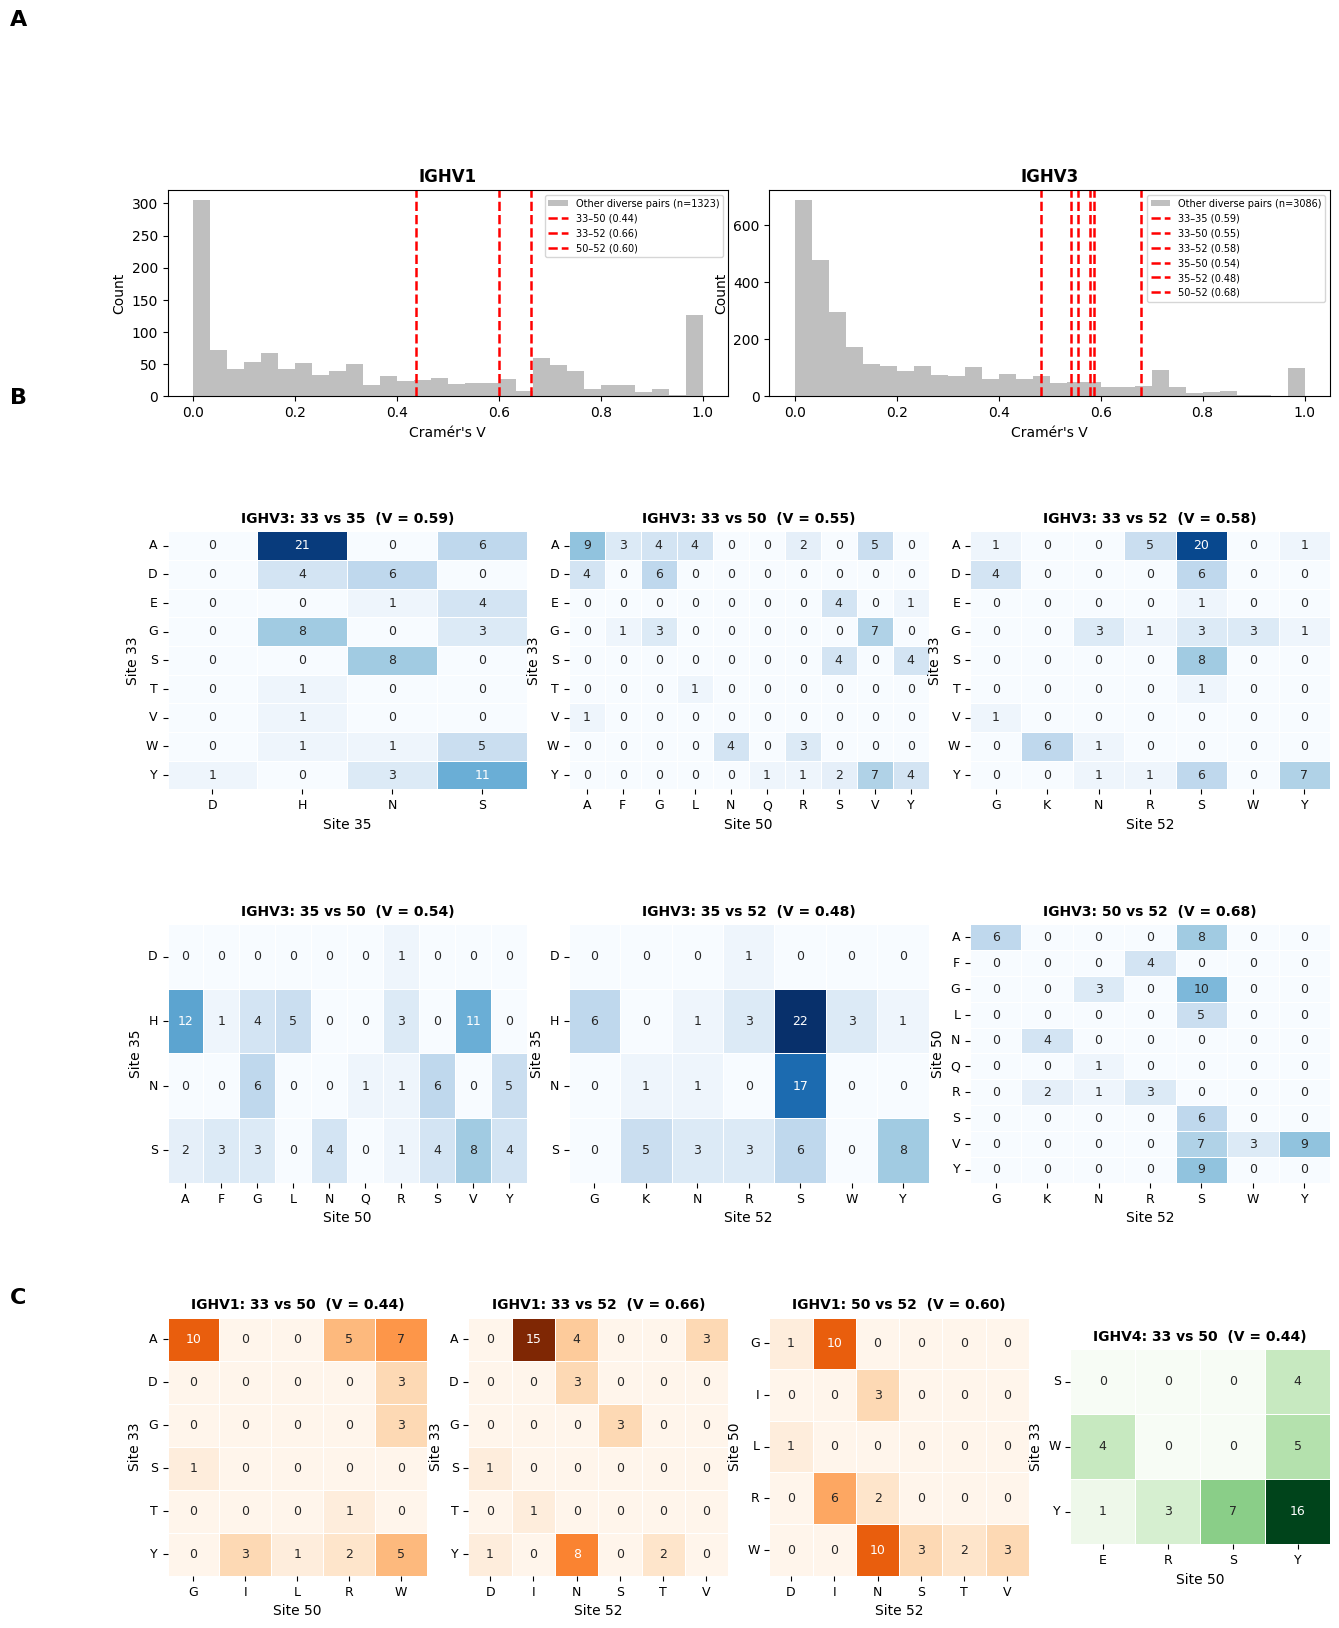

Saved to figures/entrenched_sites_germline_linkage.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib.ticker as mticker

# Sites of interest for this figure (exclude 53)
target_sites = {'33', '35', '50', '52'}

# --- Collect histogram data for IGHV1 and IGHV3 ---
family_data = {}
for v_family in ['IGHV1', 'IGHV3']:
    ent_in_family = set(
        within_entrenched[within_entrenched['v_family'] == v_family]['site'].unique()
    )
    highlight_sites = ent_in_family & target_sites

    family_codons_fam = codons_df[codons_df['v_family'] == v_family].copy()
    diverse_sites = (
        family_codons_fam.groupby('site')['amino_acid']
        .nunique()
        .loc[lambda x: x > 1]
        .index.tolist()
    )
    pivot = family_codons_fam[family_codons_fam['site'].isin(diverse_sites)].pivot(
        index='v_gene', columns='site', values='amino_acid'
    )
    all_pairs = []
    for sa, sb in combinations(diverse_sites, 2):
        if sa not in pivot.columns or sb not in pivot.columns:
            continue
        pair_df = pivot[[sa, sb]].dropna()
        if len(pair_df) < 5:
            continue
        ct = pd.crosstab(pair_df[sa], pair_df[sb])
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue
        v, p = cramers_v(ct)
        is_ent = (sa in highlight_sites) and (sb in highlight_sites)
        all_pairs.append({
            'site_a': sa, 'site_b': sb,
            'cramers_v': v, 'entrenched_pair': is_ent,
        })
    family_data[v_family] = pd.DataFrame(all_pairs)

# --- Build contingency tables per V family for target sites ---
families_ct = {}
for v_family in ['IGHV1', 'IGHV3', 'IGHV4']:
    ent_sites = set(
        within_entrenched[within_entrenched['v_family'] == v_family]['site'].unique()
    )
    sites_to_use = sort_antibody_sites([s for s in target_sites if s in ent_sites])

    family_codons_fam = codons_df[codons_df['v_family'] == v_family].copy()
    pivot_fam = family_codons_fam[family_codons_fam['site'].isin(sites_to_use)].pivot(
        index='v_gene', columns='site', values='amino_acid'
    )

    pairs_list = []
    for sa, sb in combinations(sites_to_use, 2):
        if sa not in pivot_fam.columns or sb not in pivot_fam.columns:
            continue
        pair_df = pivot_fam[[sa, sb]].dropna()
        ct = pd.crosstab(pair_df[sa], pair_df[sb])
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue
        v_val, _ = cramers_v(ct)
        pairs_list.append((sa, sb, ct, v_val))
    families_ct[v_family] = pairs_list

# --- Figure layout (12-column grid to fit 4 panels in row 3) ---
fig = plt.figure(figsize=(15, 18))
gs = gridspec.GridSpec(4, 12, figure=fig, hspace=0.55, wspace=0.70,
                       height_ratios=[0.8, 1.0, 1.0, 1.0])

# --- Row 0 (A): Histograms ---
for col_start, v_family in [(0, 'IGHV1'), (6, 'IGHV3')]:
    ax = fig.add_subplot(gs[0, col_start:col_start+6])
    df = family_data[v_family]
    ent = df[df['entrenched_pair']]
    non_ent = df[~df['entrenched_pair']]

    ax.hist(non_ent['cramers_v'], bins=30, alpha=0.5, color='gray',
            label=f'Other diverse pairs (n={len(non_ent)})')
    for _, row in ent.iterrows():
        ax.axvline(row['cramers_v'], color='red', linewidth=1.8, linestyle='--',
                   label=f"{row['site_a']}–{row['site_b']} ({row['cramers_v']:.2f})")
    ax.set_xlabel("Cramér's V", fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(v_family, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')


def plot_contingency_heatmap(ax, ct, sa, sb, v_val, family_label, cmap, vmax,
                              square=False):
    """Plot a single contingency table heatmap with clean formatting."""
    n_rows, n_cols = ct.shape
    row_labels = [str(x) for x in ct.index]
    col_labels = [str(x) for x in ct.columns]

    sns.heatmap(ct, annot=True, fmt='d', cmap=cmap,
                cbar=False, linewidths=0.5, linecolor='white',
                ax=ax, vmin=0, vmax=vmax,
                annot_kws={'size': 9},
                xticklabels=False, yticklabels=False,
                square=square)

    # Manually set tick positions and labels
    ax.set_yticks([i + 0.5 for i in range(n_rows)])
    ax.set_yticklabels(row_labels, rotation=0, fontsize=9, va='center')
    ax.set_xticks([i + 0.5 for i in range(n_cols)])
    ax.set_xticklabels(col_labels, rotation=0, fontsize=9, ha='center')

    # Disable minor ticks
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_minor_locator(mticker.NullLocator())

    ax.set_xlabel(f'Site {sb}', fontsize=10)
    ax.set_ylabel(f'Site {sa}', fontsize=10)
    ax.set_title(f'{family_label}: {sa} vs {sb}  (V = {v_val:.2f})',
                 fontsize=10, fontweight='bold')


# --- Rows 1-2 (B): IGHV3 contingency tables (6 panels) ---
max_count_v3 = max(t[2].values.max() for t in families_ct['IGHV3'])
for i, (sa, sb, ct, v_val) in enumerate(families_ct['IGHV3']):
    row_idx = 1 + i // 3
    col_idx = (i % 3) * 4
    ax = fig.add_subplot(gs[row_idx, col_idx:col_idx+4])
    plot_contingency_heatmap(ax, ct, sa, sb, v_val, 'IGHV3', 'Blues', max_count_v3)

# --- Row 3 (C): IGHV1 (3 panels) + IGHV4 (1 panel) ---
max_count_v1 = max(t[2].values.max() for t in families_ct['IGHV1'])
for i, (sa, sb, ct, v_val) in enumerate(families_ct['IGHV1']):
    col_idx = i * 3
    ax = fig.add_subplot(gs[3, col_idx:col_idx+3])
    plot_contingency_heatmap(ax, ct, sa, sb, v_val, 'IGHV1', 'Oranges', max_count_v1)

if families_ct['IGHV4']:
    sa, sb, ct, v_val = families_ct['IGHV4'][0]
    ax = fig.add_subplot(gs[3, 9:12])
    plot_contingency_heatmap(ax, ct, sa, sb, v_val, 'IGHV4', 'Greens',
                              ct.values.max(), square=True)

# Panel labels
fig.text(0.02, 0.98, 'A', fontsize=16, fontweight='bold', va='top')
fig.text(0.02, 0.77, 'B', fontsize=16, fontweight='bold', va='top')
fig.text(0.02, 0.27, 'C', fontsize=16, fontweight='bold', va='top')

fig.savefig('figures/entrenched_sites_germline_linkage.png', dpi=600, bbox_inches='tight')
plt.show()
print("Saved to figures/entrenched_sites_germline_linkage.png")

## Publication figure

## Summary

### Do entrenched sites co-vary with each other across V genes?

**Yes, moderately.** Entrenched site pairs have higher Cramér's V than the typical pair
of germline-diverse sites (IGHV1: median 0.60 vs 0.26; IGHV3: median 0.57 vs 0.12;
IGHV4: 0.44 vs 0.16). They are not independent.

### Is this co-variation explained by sequence distance (LD decay)?

**Partially, but not fully.** There is a weak negative correlation between Cramér's V
and sequence distance among all diverse site pairs (Spearman ρ ≈ −0.08 to −0.16).
Entrenched pairs sit above the distance-matched median — typically around the
70th–90th percentile for their distance — so their co-variation is somewhat elevated
beyond what sequence proximity alone predicts.

### Does this mean intra-chain epistasis between entrenched sites drives entrenchment?

**Not necessarily.** The co-variation measured here is at the **germline level** —
which amino acid combinations exist across V genes — and reflects V gene phylogeny.
The entrenchment detected by DASM is at the **somatic level** — which mutations are
disfavored during affinity maturation. These are different things.

Two V genes can share correlated amino acids at sites 33 and 50 (because they descended
from a recent common ancestor) while the *reason* each amino acid is maintained during
affinity maturation is still intermolecular — driven by binding partner interactions,
not by the amino acid at the other entrenched site.

### What can we conclude?

The contingency tables show **many-to-many** patterns: most amino acids at one entrenched
site co-occur with multiple amino acids at other entrenched sites. For example, in IGHV3,
A at site 33 appears with 6 different amino acids at site 50 (A, F, G, L, R, V). This is
inconsistent with rigid pairwise structural co-dependence, where you would expect strict
1-to-1 or few-to-few coupling (as seen in the non-entrenched CDR2-core pairs at V > 0.8).

The elevated co-variation likely reflects shared evolutionary history: these CDR-border
beta sheet positions tend to co-vary because closely related V genes share amino acids at
multiple positions by descent. But the pattern of co-variation is loose enough that
multiple amino acid combinations are viable in the intra-chain context, consistent with
the constraint on each individual site arising from outside the heavy chain.

### Implication for the paper

The germline diversity argument (main.tex lines 311–313) should not claim that entrenched
sites vary independently — they don't. Rather, the argument should be framed as: multiple
amino acid combinations coexist at these positions across V genes within a family,
indicating that no single combination is structurally required by intra-chain constraints
alone. This is consistent with the binding-partner interactions revealed by the RSA and
contact analyses being the primary source of the somatic-level entrenchment.